In [ ]:
import pandas as pd
import openpyxl

#replace the file path with final_gt_chunks.csv or final_gt_sentences.csv file path.
df_updated = pd.read_csv('data/temp/final_gt_main.csv')


#replace the file path with results from different models and data sets.
df_sen_result = pd.read_csv('data/temp/Main_Distilbert-base-uncased-finetuned-sst-2-english.csv')

In [12]:
#extract predicted labels from results using text

df_extracted = df_sen_result[df_sen_result['text'].isin(df_updated['text'])]

In [12]:
#creating function to viz confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

def plot_confusion_matrix(true_labels, predicted_labels, title):
    labels = sorted(true_labels.unique())  # get unique label names
    cm = confusion_matrix(true_labels, predicted_labels, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,   # show label names on x axis
                yticklabels=labels)   # show label names on y axis
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [9]:
df_updated['sentiment_label'] = df_updated['sentiment_label'].str.strip().str.lower()

In [10]:
df_extracted['sentiment_label'] = df_extracted['sentiment_label'].str.strip().str.lower()

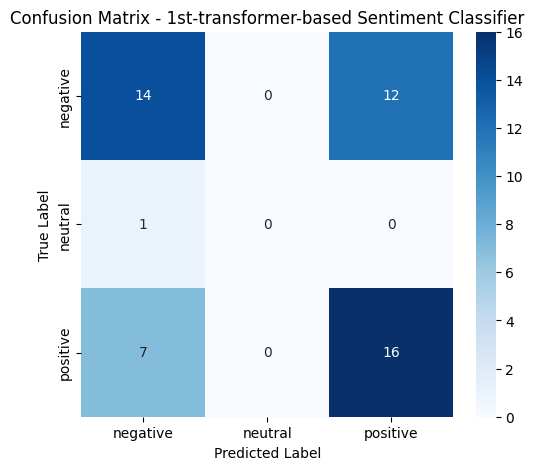

In [18]:
plot_confusion_matrix(df_updated['sentiment_label'],df_extracted['sentiment_label'],'Confusion Matrix - 1st-transformer-based Sentiment Classifier')

In [19]:
def calculate_metrics(true_labels, predicted_labels, classifier_name):
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='weighted')
    recall = recall_score(true_labels, predicted_labels, average='weighted')
    f1 = f1_score(true_labels, predicted_labels, average='weighted')

    print(f"\n--- {classifier_name} Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Per class metrics
    print(f"\n--- Per Class Report ---")
    print(classification_report(true_labels, predicted_labels))
    
    return accuracy, precision, recall, f1

calculate_metrics(df_updated['sentiment_label'], df_extracted['sentiment_label'], 'Confusion Matrix - 1st-transformer-based Sentiment Classifier')


--- Confusion Matrix - 1st-transformer-based Sentiment Classifier Performance ---
Accuracy: 0.6000
Precision: 0.5938
Recall: 0.6000
F1 Score: 0.5920

--- Per Class Report ---
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58        26
     neutral       0.00      0.00      0.00         1
    positive       0.57      0.70      0.63        23

    accuracy                           0.60        50
   macro avg       0.40      0.41      0.40        50
weighted avg       0.59      0.60      0.59        50



d:\UCD\LLM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\UCD\LLM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\UCD\LLM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\UCD\LLM\.venv\Lib\site-packages\sklearn\metrics\_

(0.6, 0.5937662337662338, 0.6, 0.5919607843137256)